<a href="https://colab.research.google.com/github/MateoGlz/Progra-Analitica-Descriptica-Predictiva/blob/main/27_Tarea_SVM_Clases_No_Balanceadas_Mateo_Gonzalez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Tarea: Clasificación con SVM en un contexto de Clases No Balanceadas

**Nivel:** Maestría  
**Duración estimada:** 2-3 horas  
**Herramientas:** Python, Scikit-Learn, imbalanced-learn, Matplotlib, Google Colab  
**Temas clave:**  
- Clasificación con SVM  
- Clases no balanceadas  
- Validación cruzada estratificada  
- Métricas adaptadas a desbalance  
- SMOTE y otras técnicas de remuestreo


## 🧾 Objetivos de aprendizaje

Al finalizar esta tarea, el estudiante será capaz de:

- Identificar los efectos del desbalance de clases en modelos clasificadores.
- Implementar una SVM en un escenario multiclase o binario con fuerte desbalance.
- Evaluar el rendimiento del modelo usando métricas robustas como recall, F1, y G-mean.
- Aplicar técnicas como SMOTE y comparar su impacto.
- Utilizar `StratifiedKFold` para asegurar la adecuada evaluación del modelo.


## 🔧 Instrucciones

1. **Carga y exploración del dataset**
   - Utiliza el dataset `breast_cancer` o `wine` de Scikit-Learn.
   - Verifica la distribución de clases.
   - Visualiza con un gráfico la distribución y las principales características.

2. **Entrenamiento base con SVM**
   - Usa un modelo SVM con kernel RBF.
   - Aplica `StratifiedKFold` con 5 particiones.
   - Evalúa con métricas por clase: precisión, recall, F1-score.
   - Calcula y reporta métricas promedio y por clase.

3. **Análisis del problema de desbalance**
   - Interpreta las métricas: ¿qué clase tiene peor desempeño? ¿por qué?
   - Reporta matriz de confusión promedio.

4. **Aplicación de SMOTE**
   - Aplica `SMOTE` solo al conjunto de entrenamiento dentro de cada fold.
   - Entrena nuevamente la SVM.
   - Compara métricas antes y después.

5. **Visualización y conclusiones**
   - Usa un gráfico de barras comparando F1 por clase antes y después.
   - Comenta las ventajas y riesgos de aplicar SMOTE con SVM.
   - Explica cuándo conviene usar otras técnicas como `One-Sided Selection` o `ADASYN`.


## 📁 Entregables

- Google Colab Notebook con:
  - Código bien comentado
  - Gráficas solicitadas
  - Conclusiones reflexivas al final
- Exportación del notebook a PDF


In [ ]:
!pip install imbalanced-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE


data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print("Distribución de clases:")
print(df['diagnosis'].value_counts())
print("\nPorcentajes:")
print(df['diagnosis'].value_counts(normalize=True) * 100)

Distribución de clases:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Porcentajes:
diagnosis
Benign       62.741652
Malignant    37.258348
Name: proportion, dtype: float64


In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

# DEFINIR COLORES CONSISTENTES
# Benign = ROJO, Malignant = VERDE
COLORES = {'Benign': 'green', 'Malignant': 'red'}

/tmp/ipython-input-669237061.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


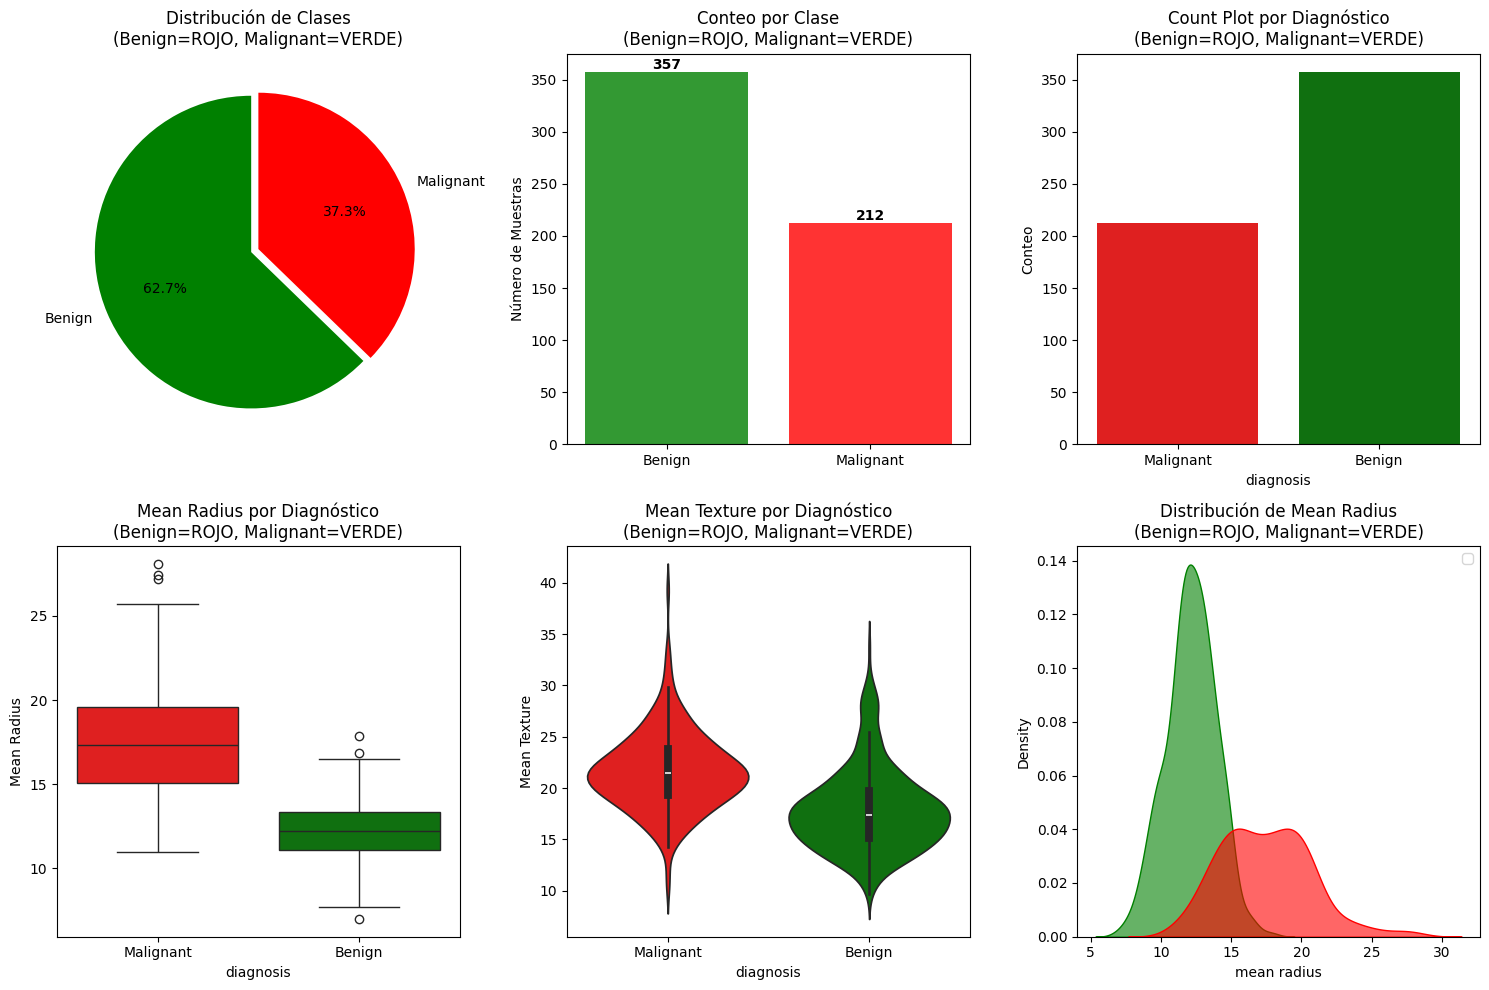

In [ ]:
# VISUALIZACIÓN CON COLORES CONSISTENTES (CÓDIGO CORREGIDO)
plt.figure(figsize=(15, 10))

# 1. PIE CHART - Distribución porcentual
plt.subplot(2, 3, 1)
class_counts = df['diagnosis'].value_counts()
colors_pie = [COLORES['Benign'], COLORES['Malignant']]  # Benign=Rojo, Malignant=Verde
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, explode=(0.05, 0))
plt.title('Distribución de Clases\n(Benign=ROJO, Malignant=VERDE)')

# 2. BAR PLOT - Conteo absoluto
plt.subplot(2, 3, 2)
bars = plt.bar(class_counts.index, class_counts.values,
               color=[COLORES['Benign'], COLORES['Malignant']], alpha=0.8)
plt.title('Conteo por Clase\n(Benign=ROJO, Malignant=VERDE)')
plt.ylabel('Número de Muestras')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}', ha='center', va='bottom', fontweight='bold')

# 3. COUNT PLOT (CORREGIDO)
plt.subplot(2, 3, 3)
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette=COLORES, legend=False)
plt.title('Count Plot por Diagnóstico\n(Benign=ROJO, Malignant=VERDE)')
plt.ylabel('Conteo')

# 4. BOXPLOT de Mean Radius (CORREGIDO)
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='diagnosis', y='mean radius', hue='diagnosis', palette=COLORES, legend=False)
plt.title('Mean Radius por Diagnóstico\n(Benign=ROJO, Malignant=VERDE)')
plt.ylabel('Mean Radius')

# 5. VIOLIN PLOT de Mean Texture (CORREGIDO)
plt.subplot(2, 3, 5)
sns.violinplot(data=df, x='diagnosis', y='mean texture', hue='diagnosis', palette=COLORES, legend=False)
plt.title('Mean Texture por Diagnóstico\n(Benign=ROJO, Malignant=VERDE)')
plt.ylabel('Mean Texture')

# 6. KDE PLOT (CORREGIDO - ya estaba bien)
plt.subplot(2, 3, 6)
sns.kdeplot(data=df, x='mean radius', hue='diagnosis', fill=True, palette=COLORES, alpha=0.6)
plt.title('Distribución de Mean Radius\n(Benign=ROJO, Malignant=VERDE)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
all_metrics = []
X = data.data
y = data.target
svm_model = SVC(kernel='rbf', random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm_model.fit(X_train_scaled, y_train)
    y_pred = svm_model.predict(X_test_scaled)


    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    f1_per_class = f1_score(y_test, y_pred, average=None)
    accuracy = accuracy_score(y_test, y_pred)


    precision_avg = precision_score(y_test, y_pred, average='weighted')
    recall_avg = recall_score(y_test, y_pred, average='weighted')
    f1_avg = f1_score(y_test, y_pred, average='weighted')

    # Guardar resultados
    fold_metrics = {
        'fold': fold,
        'precision_class': precision_per_class,
        'recall_class': recall_per_class,
        'f1_class': f1_per_class,
        'precision_avg': precision_avg,
        'recall_avg': recall_avg,
        'f1_avg': f1_avg,
        'accuracy': accuracy,
        'y_test': y_test,
        'y_pred': y_pred
    }
    all_metrics.append(fold_metrics)


    print(f"\n FOLD {fold}:")
    print(f"   Accuracy: {accuracy:.4f}")

    print("    POR CLASE:")
    print(f"      Clase 0 (Malignant) - Precision: {precision_per_class[0]:.4f}, Recall: {recall_per_class[0]:.4f}, F1: {f1_per_class[0]:.4f}")
    print(f"      Clase 1 (Benign)    - Precision: {precision_per_class[1]:.4f}, Recall: {recall_per_class[1]:.4f}, F1: {f1_per_class[1]:.4f}")

    print("    PROMEDIOS:")
    print(f"      Precision: {precision_avg:.4f}, Recall: {recall_avg:.4f}, F1: {f1_avg:.4f}")


print("\n" + "=" * 60)
print("MÉTRICAS PROMEDIO DE TODOS LOS FOLDS")
print("=" * 60)

# Calcular promedios de todos los folds
avg_precision_class_0 = np.mean([m['precision_class'][0] for m in all_metrics])
avg_recall_class_0 = np.mean([m['recall_class'][0] for m in all_metrics])
avg_f1_class_0 = np.mean([m['f1_class'][0] for m in all_metrics])

avg_precision_class_1 = np.mean([m['precision_class'][1] for m in all_metrics])
avg_recall_class_1 = np.mean([m['recall_class'][1] for m in all_metrics])
avg_f1_class_1 = np.mean([m['f1_class'][1] for m in all_metrics])

avg_precision_total = np.mean([m['precision_avg'] for m in all_metrics])
avg_recall_total = np.mean([m['recall_avg'] for m in all_metrics])
avg_f1_total = np.mean([m['f1_avg'] for m in all_metrics])
avg_accuracy = np.mean([m['accuracy'] for m in all_metrics])

print("\n MÉTRICAS POR CLASE (promedio de 5 folds):")
print(f"    Clase 0 (Malignant):")
print(f"      Precision: {avg_precision_class_0:.4f}")
print(f"      Recall:    {avg_recall_class_0:.4f}")
print(f"      F1-score:  {avg_f1_class_0:.4f}")

print(f"\n    Clase 1 (Benign):")
print(f"      Precision: {avg_precision_class_1:.4f}")
print(f"      Recall:    {avg_recall_class_1:.4f}")
print(f"      F1-score:  {avg_f1_class_1:.4f}")

print("\n MÉTRICAS PROMEDIO (weighted):")
print(f"   Precision: {avg_precision_total:.4f}")
print(f"   Recall:    {avg_recall_total:.4f}")
print(f"   F1-score:  {avg_f1_total:.4f}")
print(f"   Accuracy:  {avg_accuracy:.4f}")


 FOLD 1:
   Accuracy: 0.9912
    POR CLASE:
      Clase 0 (Malignant) - Precision: 0.9773, Recall: 1.0000, F1: 0.9885
      Clase 1 (Benign)    - Precision: 1.0000, Recall: 0.9859, F1: 0.9929
    PROMEDIOS:
      Precision: 0.9914, Recall: 0.9912, F1: 0.9912

 FOLD 2:
   Accuracy: 0.9474
    POR CLASE:
      Clase 0 (Malignant) - Precision: 0.9512, Recall: 0.9070, F1: 0.9286
      Clase 1 (Benign)    - Precision: 0.9452, Recall: 0.9718, F1: 0.9583
    PROMEDIOS:
      Precision: 0.9475, Recall: 0.9474, F1: 0.9471

 FOLD 3:
   Accuracy: 0.9737
    POR CLASE:
      Clase 0 (Malignant) - Precision: 1.0000, Recall: 0.9286, F1: 0.9630
      Clase 1 (Benign)    - Precision: 0.9600, Recall: 1.0000, F1: 0.9796
    PROMEDIOS:
      Precision: 0.9747, Recall: 0.9737, F1: 0.9735

 FOLD 4:
   Accuracy: 0.9912
    POR CLASE:
      Clase 0 (Malignant) - Precision: 0.9767, Recall: 1.0000, F1: 0.9882
      Clase 1 (Benign)    - Precision: 1.0000, Recall: 0.9861, F1: 0.9930
    PROMEDIOS:
      Precis


Metricas Malignant: Precision=0.981, Recall=0.958, F1=0.969
Metricas Benign:    Precision=0.976, Recall=0.989, F1=0.982

Clase con peor desempenio: MALIGNANT
Razon: Tiene menor F1-score


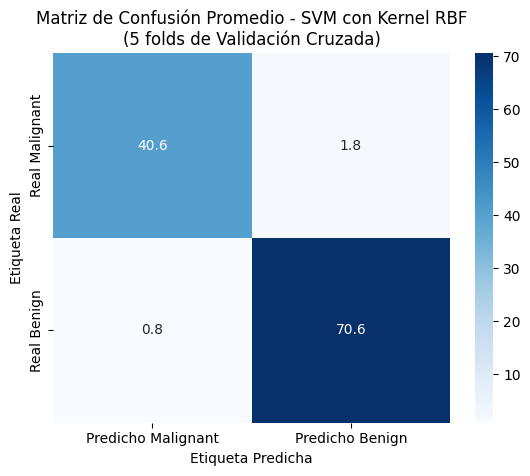

In [ ]:
conf_matrices = []
for metrics in all_metrics:
    cm = confusion_matrix(metrics['y_test'], metrics['y_pred'])
    conf_matrices.append(cm)

conf_matrix_avg = np.mean(conf_matrices, axis=0)

sns.heatmap(conf_matrix_avg, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Predicho Malignant', 'Predicho Benign'],
            yticklabels=['Real Malignant', 'Real Benign'])

plt.title('Matriz de Confusión Promedio - SVM con Kernel RBF\n(5 folds de Validación Cruzada)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')

# Tercero: Interpretar métricas
avg_precision_malignant = np.mean([m['precision_class'][0] for m in all_metrics])
avg_recall_malignant = np.mean([m['recall_class'][0] for m in all_metrics])
avg_f1_malignant = np.mean([m['f1_class'][0] for m in all_metrics])

avg_precision_benign = np.mean([m['precision_class'][1] for m in all_metrics])
avg_recall_benign = np.mean([m['recall_class'][1] for m in all_metrics])
avg_f1_benign = np.mean([m['f1_class'][1] for m in all_metrics])

print(f"\nMetricas Malignant: Precision={avg_precision_malignant:.3f}, Recall={avg_recall_malignant:.3f}, F1={avg_f1_malignant:.3f}")
print(f"Metricas Benign:    Precision={avg_precision_benign:.3f}, Recall={avg_recall_benign:.3f}, F1={avg_f1_benign:.3f}")

# Determinar clase con peor desempeño
if avg_f1_malignant < avg_f1_benign:
    peor_clase = "MALIGNANT"
    razon = "Tiene menor F1-score"
else:
    peor_clase = "BENIGN"
    razon = "Tiene menor F1-score"

print(f"\nClase con peor desempenio: {peor_clase}")
print(f"Razon: {razon}")

In [ ]:

all_metrics_smote = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

    # Dividir datos
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    #  APLICAR SMOTE solo al conjunto de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f"Fold {fold}:")
    print(f"  Training original - Malignant: {sum(y_train == 0)}, Benign: {sum(y_train == 1)}")
    print(f"  Training con SMOTE - Malignant: {sum(y_train_smote == 0)}, Benign: {sum(y_train_smote == 1)}")

    # Escalar los datos (usando los datos con SMOTE para entrenamiento)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_smote)  # Usar datos con SMOTE
    X_test_scaled = scaler.transform(X_test)              # Usar datos originales de test

    # Entrenar y predecir
    svm_model.fit(X_train_scaled, y_train_smote)  # Entrenar con datos balanceados
    y_pred = svm_model.predict(X_test_scaled)     # Predecir con datos originales

    # Calcular métricas
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    f1_per_class = f1_score(y_test, y_pred, average=None)
    accuracy = accuracy_score(y_test, y_pred)

    # Guardar resultados
    fold_metrics = {
        'fold': fold,
        'precision_class': precision_per_class,
        'recall_class': recall_per_class,
        'f1_class': f1_per_class,
        'accuracy': accuracy,
        'y_test': y_test,
        'y_pred': y_pred
    }
    all_metrics_smote.append(fold_metrics)

# Calcular métricas promedio con SMOTE
avg_precision_malignant_smote = np.mean([m['precision_class'][0] for m in all_metrics_smote])
avg_recall_malignant_smote = np.mean([m['recall_class'][0] for m in all_metrics_smote])
avg_f1_malignant_smote = np.mean([m['f1_class'][0] for m in all_metrics_smote])

avg_precision_benign_smote = np.mean([m['precision_class'][1] for m in all_metrics_smote])
avg_recall_benign_smote = np.mean([m['recall_class'][1] for m in all_metrics_smote])
avg_f1_benign_smote = np.mean([m['f1_class'][1] for m in all_metrics_smote])
avg_accuracy_smote = np.mean([m['accuracy'] for m in all_metrics_smote])


print("\n MALIGNANT (Clase minoritaria):")
print(f"  SIN SMOTE  - Precision: {avg_precision_malignant:.3f}, Recall: {avg_recall_malignant:.3f}, F1: {avg_f1_malignant:.3f}")
print(f"  CON SMOTE  - Precision: {avg_precision_malignant_smote:.3f}, Recall: {avg_recall_malignant_smote:.3f}, F1: {avg_f1_malignant_smote:.3f}")

print("\n BENIGN (Clase mayoritaria):")
print(f"  SIN SMOTE  - Precision: {avg_precision_benign:.3f}, Recall: {avg_recall_benign:.3f}, F1: {avg_f1_benign:.3f}")
print(f"  CON SMOTE  - Precision: {avg_precision_benign_smote:.3f}, Recall: {avg_recall_benign_smote:.3f}, F1: {avg_f1_benign_smote:.3f}")

print(f"\n ACCURACY GENERAL:")
print(f"  SIN SMOTE: {np.mean([m['accuracy'] for m in all_metrics]):.3f}")
print(f"  CON SMOTE: {avg_accuracy_smote:.3f}")

# Matriz de confusión con SMOTE
conf_matrices_smote = []
for metrics in all_metrics_smote:
    cm = confusion_matrix(metrics['y_test'], metrics['y_pred'])
    conf_matrices_smote.append(cm)

conf_matrix_avg_smote = np.mean(conf_matrices_smote, axis=0)

print(f"\n MATRIZ DE CONFUSIÓN CON SMOTE:")
print(conf_matrix_avg_smote)

Fold 1:
  Training original - Malignant: 169, Benign: 286
  Training con SMOTE - Malignant: 286, Benign: 286
Fold 2:
  Training original - Malignant: 169, Benign: 286
  Training con SMOTE - Malignant: 286, Benign: 286
Fold 3:
  Training original - Malignant: 170, Benign: 285
  Training con SMOTE - Malignant: 285, Benign: 285
Fold 4:
  Training original - Malignant: 170, Benign: 285
  Training con SMOTE - Malignant: 285, Benign: 285
Fold 5:
  Training original - Malignant: 170, Benign: 286
  Training con SMOTE - Malignant: 286, Benign: 286

 MALIGNANT (Clase minoritaria):
  SIN SMOTE  - Precision: 0.981, Recall: 0.958, F1: 0.969
  CON SMOTE  - Precision: 0.963, Recall: 0.958, F1: 0.960

 BENIGN (Clase mayoritaria):
  SIN SMOTE  - Precision: 0.976, Recall: 0.989, F1: 0.982
  CON SMOTE  - Precision: 0.975, Recall: 0.978, F1: 0.976

 ACCURACY GENERAL:
  SIN SMOTE: 0.977
  CON SMOTE: 0.970

 MATRIZ DE CONFUSIÓN CON SMOTE:
[[40.6  1.8]
 [ 1.6 69.8]]


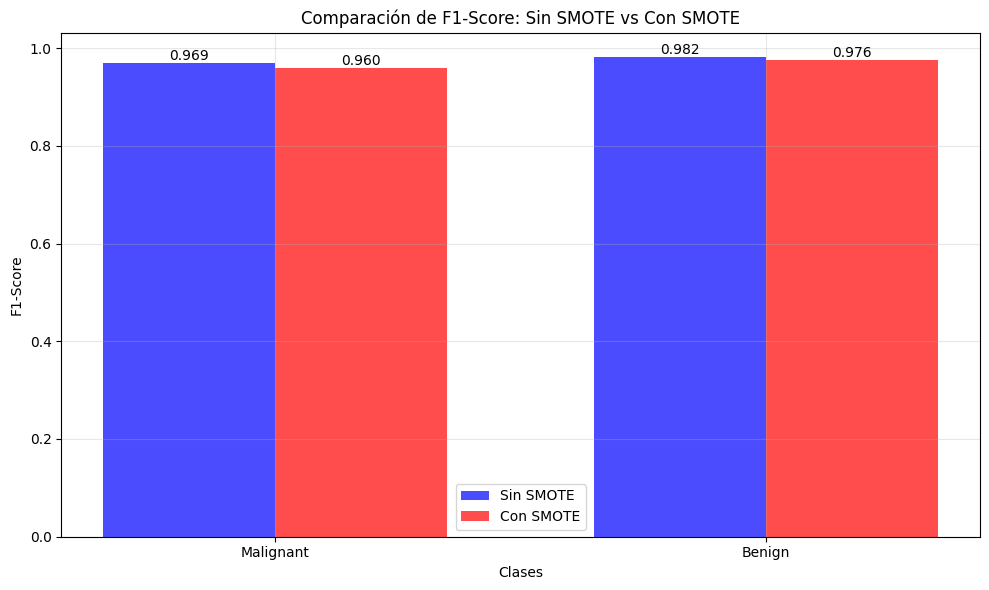

In [ ]:
# Gráfico usando las variables existentes
clases = ['Malignant', 'Benign']
f1_sin_smote = [avg_f1_malignant, avg_f1_benign]
f1_con_smote = [avg_f1_malignant_smote, avg_f1_benign_smote]

x = np.arange(len(clases))
ancho = 0.35

plt.figure(figsize=(10, 6))
barras1 = plt.bar(x - ancho/2, f1_sin_smote, ancho, label='Sin SMOTE', color='blue', alpha=0.7)
barras2 = plt.bar(x + ancho/2, f1_con_smote, ancho, label='Con SMOTE', color='red', alpha=0.7)

plt.xlabel('Clases')
plt.ylabel('F1-Score')
plt.title('Comparación de F1-Score: Sin SMOTE vs Con SMOTE')
plt.xticks(x, clases)
plt.legend()
plt.grid(True, alpha=0.3)

# Añadir valores en las barras
for barra in barras1:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:.3f}', ha='center', va='bottom')

for barra in barras2:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Comenta las ventajas y riesgos de aplicar SMOTE con SVM.**

Lo que hace SMOTE es igualar para que ambas clases estan balanciadas y no tenga un sesgo devido a que aprendio mas de alguno debido a que hay mas. En general ayuda para reducir los *Falsos Negativos*.

Un detalle seria que puede aprender con datos sinteticos aprendiendo patrones que no existen. En esto entra el que los casos atipicos los camuflagea con los demas pareciendo que no existen estos.
Ademas que los falsos positivos pueden incrementar en mi caso se duplicaron de 0.8 a 1.6, aunque desconozco si suelen duplicarse o solo tienen un incremento considerable.

**Explica cuándo conviene usar otras técnicas como One-Sided Selection o ADASYN.**

*One-Sided Selection*

 Cuando existe mucho ruido en al distribucion de los datos o cuando son muy grandes tambien, pero sin afectarlos por datos sinteticos ya que casos atipicos son necesarios, son reales. Ya que produci MENOS falsos positivos si este factor es determinante o mas importante para un modelo se puede optar

*ADASYN*

Se implementa cuando los datos son parecidos y no hay una separacion entre estas, el error no puede ocurrir o en otras palabras los falsos negativos tienen un costo alto. Te faltan datos e un subtipo.
